# Notebook - Find best Drug compound for `Bacillus Anthracis` bacteria. This bacteria is responsible for anthrax disease.

Data source: `PubChem + ChEMBL`

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [54]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [55]:
import csv
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from joblib import load
from PIL import Image
import json, pickle
import gc
from joblib import Parallel, delayed
from copy import deepcopy


sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600
from matplotlib.ticker import AutoMinorLocator
from scipy.stats import gaussian_kde


from copy import deepcopy
from joblib import Parallel, delayed
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%run "./plotting.py"

1.0.1


In [56]:
%config InlineBackend.figure_format = 'retina'

In [57]:
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from transformers.onnx import OnnxConfig

from art.core import RecommendationEngine
import art.utility as utils
from art.plot import predictions_vs_observations, predictions_distr_vs_observations
import pickle
import cloudpickle

import io
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage

In [58]:
import pubchempy as pcp
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from admet_ai import ADMETModel
from admet_ai.drugbank import get_drugbank
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines, math
from scipy.stats import percentileofscore

## 1. Training Data preparation

In [59]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
HuggingFaceModelsDir = os.path.join(dataDir, 'HuggingFace_models/')
DORANETmoleculesDataDir = '/users/sghosh6/DTRA_project/MACAW/doranet/scripts'
resultsDir = os.path.join(dataDir, 'Results/BacillusAnthracis_bestMACAW_allDB_generative/')
os.makedirs(resultsDir, exist_ok=True)

### 1.1 Read potency data for BacillusAnthracis Bacteria from `ChEMBL`

In [60]:
allBacteriaData_chEMBL = pd.read_csv(modelBuildingDataDir + 'allBacteriaData_chEMBL_uM.csv')

allBacteriaData_chEMBL = allBacteriaData_chEMBL.rename(
    columns={'Virus': 'Bacteria'})
allBacteriaData_chEMBL = allBacteriaData_chEMBL.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Bacteria"]
)
allBacteriaData_chEMBL['Bacteria'] = allBacteriaData_chEMBL['Bacteria'].str.replace('Data_chEMBL_combined.csv', '', regex=False)
allBacteriaData_chEMBL.rename(columns={'Bacteria': 'BacteriaClassifier'}, inplace=True)
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,BacteriaClassifier
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilis
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilis
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilis
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilis
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilis
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,3.200000e+01,4.494850,Yersinia_pestis
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.660000e+01,4.331614,Yersinia_pestis
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000000e-250,256.000000,Yersinia_pestis
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000000e+00,5.397940,Yersinia_pestis


### Keep only data for `Bacillus_anthracis` bacteria

In [61]:
BacillusAnthracisData_chEMBL = allBacteriaData_chEMBL[allBacteriaData_chEMBL['BacteriaClassifier'] == 'Bacillus_anthracis']
BacillusAnthracisData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,BacteriaClassifier
162379,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,7.585776e+05,0.12,Bacillus_anthracis
162380,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162381,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162382,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162383,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,1.000000e+04,2.00,Bacillus_anthracis
...,...,...,...,...,...
163230,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,1.000000e+01,5.00,Bacillus_anthracis
163231,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],1.000000e-44,50.00,Bacillus_anthracis
163232,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,1.000000e-194,200.00,Bacillus_anthracis
163233,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,1.584893e-02,7.80,Bacillus_anthracis


### Rename columns

In [62]:
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "BacteriaClassifier" : "Bacteria",
})
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL.filter(
    items=["Bacteria", "compound_id", "Smiles", "pPotency"])
BacillusAnthracisData_chEMBL

,Bacteria,compound_id,Smiles,pPotency
162379,Bacillus_anthracis,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.12
162380,Bacillus_anthracis,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00
162381,Bacillus_anthracis,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00
162382,Bacillus_anthracis,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00
162383,Bacillus_anthracis,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,2.00
...,...,...,...,...
163230,Bacillus_anthracis,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.00
163231,Bacillus_anthracis,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.00
163232,Bacillus_anthracis,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.00
163233,Bacillus_anthracis,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.80


### 1.2 Read `Pubchem` bioassay data for BacillusAnthracis Bacteria

In [63]:
BacillusAnthracisData_Pubchem = pd.read_csv(os.path.join(modelBuildingDataDir, "allBacteria_Pubchem.csv"))
# Keep only data for Bacillus_anthracis Bacteria
BacillusAnthracisData_Pubchem = BacillusAnthracisData_Pubchem[BacillusAnthracisData_Pubchem['Bacteria'] == 'Bacillus_anthracis']
BacillusAnthracisData_Pubchem

,Bacteria,compound_id,Smiles,pPotency
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996
...,...,...,...,...
3477,Bacillus_anthracis,7117403,O=C(C(=O)N1CC=C(c2ccccc2)CC1)c1c[nH]c2ccccc12,4.920819
3478,Bacillus_anthracis,54595320,N#Cc1ccc(Oc2ccccc2O)c(F)c1,4.958607
3479,Bacillus_anthracis,43458374,CN(Cc1ccccc1N)C(=O)c1cc2ccccc2o1,4.346787
3480,Bacillus_anthracis,4117778,O=C(COc1ccccc1)NCCSc1c[nH]c2ccccc12,5.468521


### Combine `Pubchem + chEMBL` data

In [64]:
BacillusAnthracisData_allDB = pd.concat(
    [BacillusAnthracisData_Pubchem, BacillusAnthracisData_chEMBL],
    ignore_index=True
)

BacillusAnthracisData_allDB

,Bacteria,compound_id,Smiles,pPotency
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996
...,...,...,...,...
4333,Bacillus_anthracis,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000
4334,Bacillus_anthracis,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.000000
4335,Bacillus_anthracis,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.000000
4336,Bacillus_anthracis,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000


### Canonicalize the `Smiles`

In [65]:
def canonicalize_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None


BacillusAnthracisData_allDB['Smiles'] = (
    BacillusAnthracisData_allDB['Smiles']
    .astype(str)
    .apply(canonicalize_smiles)
)

BacillusAnthracisData_allDB = BacillusAnthracisData_allDB.rename(
    columns={'Smiles': 'Canonical_SMILES'})

BacillusAnthracisData_allDB

,Bacteria,compound_id,Canonical_SMILES,pPotency
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996
...,...,...,...,...
4333,Bacillus_anthracis,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000
4334,Bacillus_anthracis,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.000000
4335,Bacillus_anthracis,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.000000
4336,Bacillus_anthracis,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000


### Remove `Basidalin` from training set

In [66]:
querySmilesDict = {
    "Basidalin": "C1=C(/C(=C\C=O)/OC1=O)N",
    #"Molnupiravir": r"CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O",
    #"Favipiravir": "C1=C(N=C(C(=O)N1)C(=O)N)F",
    #"Brincidofovir": "CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O",
}

In [67]:
# Canonical SMILES set for all query drugs
queryCanonicalSet = {
    Chem.MolToSmiles(Chem.MolFromSmiles(smi), canonical=True)
    for smi in querySmilesDict.values()
    if Chem.MolFromSmiles(smi) is not None
}

# Canonicalize all SMILES in your dataframe
df = BacillusAnthracisData_allDB.copy()
df["canonical_smiles"] = df["Canonical_SMILES"].apply(
    lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
    if Chem.MolFromSmiles(s) is not None else None
)

# Remove rows whose canonical SMILES appear in querySmilesDict
df_clean = df[~df["canonical_smiles"].isin(queryCanonicalSet)].copy()

print(f"Original shape: {len(df)}")
print(f"Removed (matches any query drug): {len(df) - len(df_clean)}")
print(f"Remaining shape: {len(df_clean)}")

BacillusAnthracisData_allDB = df_clean.copy()
BacillusAnthracisData_allDB = BacillusAnthracisData_allDB.drop(columns='canonical_smiles')
BacillusAnthracisData_allDB

Original shape: 4338
Removed (matches any query drug): 0
Remaining shape: 4338


,Bacteria,compound_id,Canonical_SMILES,pPotency
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996
...,...,...,...,...
4333,Bacillus_anthracis,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000
4334,Bacillus_anthracis,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.000000
4335,Bacillus_anthracis,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.000000
4336,Bacillus_anthracis,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000


### Potency distribution

In [68]:
# bins for non-negative values: 0-3, 3-4, ..., 11-12, >12
bins = [0] + list(range(3, 13)) + [np.inf]
labels = ["0-3"] + [f"{i}-{i+1}" for i in range(3, 12)] + ["> 12"]

df = BacillusAnthracisData_allDB.copy()

# coerce to numeric (invalid entries become NaN)
p = pd.to_numeric(df["pPotency"], errors="coerce")

# build categories including NaN and negatives
cat = pd.Series(index=df.index, dtype="object")
cat[p.isna()] = "NaN"
cat[(~p.isna()) & (p < 0)] = "<0"

# categorize non-negative values
cat[(~p.isna()) & (p >= 0)] = pd.cut(
    p[(~p.isna()) & (p >= 0)],
    bins=bins,
    labels=labels,
    right=False,
    ordered=True,
)

df["pPotency_category"] = cat

order = ["NaN", "<0"] + labels
category_counts = df["pPotency_category"].value_counts().reindex(order, fill_value=0)
total = category_counts.sum()
category_percent = (category_counts / total * 100).round(2)

potencyDist = pd.DataFrame({
    "pPotency Range": category_counts.index.astype(str),
    "Count": category_counts.values,
    "Percent (%)": category_percent.values
})

potencyDist

,pPotency Range,Count,Percent (%)
0,NaN,73,1.68
1,<0,0,0.00
2,0-3,813,18.74
3,3-4,551,12.70
4,4-5,1369,31.56
5,5-6,762,17.57
6,6-7,306,7.05
7,7-8,123,2.84
8,8-9,100,2.31
9,9-10,48,1.11


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before running cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | **Keep**         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [69]:
print("Original shape:", BacillusAnthracisData_allDB.shape)

BacillusAnthracisData_allDB = BacillusAnthracisData_allDB[
    BacillusAnthracisData_allDB['pPotency'].notna()
    & BacillusAnthracisData_allDB['pPotency'].between(0, 12, inclusive="both")]

BacillusAnthracisData_allDB = BacillusAnthracisData_allDB.drop(
    columns=["canonical_smiles", "pPotency_category"],
    errors="ignore"  # prevents error if a column doesn't exist
)
print("Shape after cleaning 'pPotency' value:", BacillusAnthracisData_allDB.shape)
max_val = BacillusAnthracisData_allDB['pPotency'].max()
min_val = BacillusAnthracisData_allDB['pPotency'].min()
print(f"pPotency range in training data: {min_val:.3f} → {max_val:.3f}")

BacillusAnthracisData_allDB

Original shape: (4338, 4)
Shape after cleaning 'pPotency' value: (4082, 4)
pPotency range in training data: 0.015 → 12.000


,Bacteria,compound_id,Canonical_SMILES,pPotency
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996
...,...,...,...,...
4330,Bacillus_anthracis,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.267606
4332,Bacillus_anthracis,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.022276
4333,Bacillus_anthracis,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000
4336,Bacillus_anthracis,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000


In [70]:
BacillusAnthracisData_allDB.to_csv(resultsDir +  "BacillusAnthracisData_allDB_MLready.csv", index=False)

### Checking how many duplicate SMILES are present in the training data set

In [72]:
duplicates = BacillusAnthracisData_allDB.duplicated(subset=['Canonical_SMILES', 'Bacteria'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 2435


## 2.1 Find best `MACAW` parameters to train ML Model

### Run cross validation with best `MACAW` parameters

In [73]:
macawNComponents = 90
macawNLandmarks = 500

Model training with: 4082 instances

----------------------------------------
Cross Validation Metrics
----------------------------------------
Train: MAE 0.50 | RMSE 1.04 | R² 0.71
Test:  MAE 0.67 | RMSE 1.19 | R² 0.61
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/BacillusAnthracis_allDB_CV_wMACAW.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/BacillusAnthracis_allDB_CV_wMACAW.png


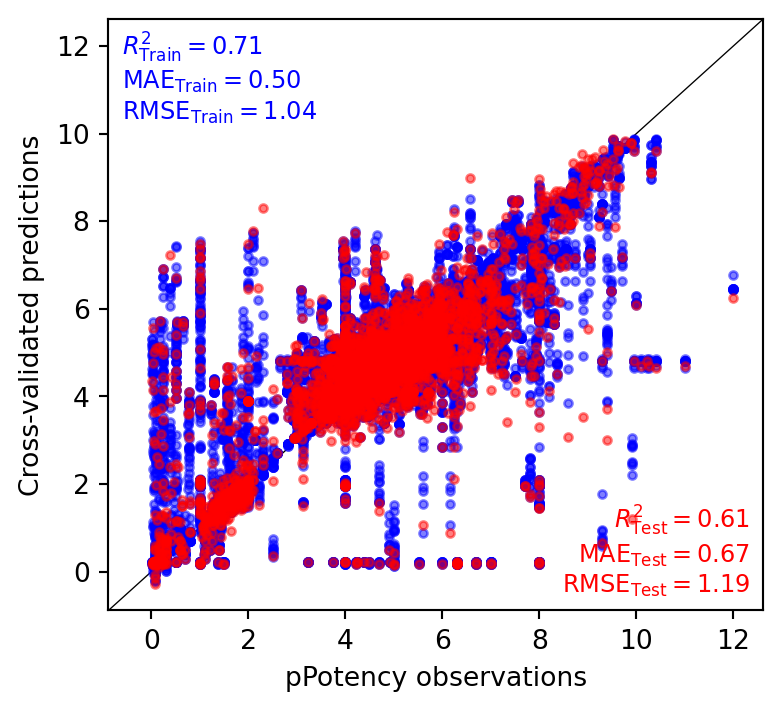

In [74]:
# --- Data ---
Y = BacillusAnthracisData_allDB["pPotency"]
smiles = BacillusAnthracisData_allDB["Canonical_SMILES"]

# CV partitions
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mcw = MACAW(
    type_fp="atompairs", metric="sokal",
    n_components=macawNComponents, n_landmarks=macawNLandmarks, random_state=42
)

param_grid = {"C": [10], "epsilon": [0.1], "gamma": ["scale"], "kernel": ["rbf"]}

# Clean NaNs in target
valid = Y.notna()
smiles = smiles[valid].reset_index(drop=True)
Y = Y[valid].reset_index(drop=True)

print(f"Model training with: {len(smiles)} instances")

def process_fold(fold_id, train_idx, test_idx):
    smi_train, smi_test = smiles.iloc[train_idx], smiles.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx].values, Y.iloc[test_idx].values

    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)

    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)

    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)

    pred_train = grid.predict(X_train)
    pred_test  = grid.predict(X_test)

    return pred_train, y_train, pred_test, y_test, grid.best_params_

folds = list(kf.split(smiles))

results = Parallel(n_jobs=4)(
    delayed(process_fold)(i + 1, tr, te) for i, (tr, te) in enumerate(folds)
)

# Concatenate CV predictions
Y_pred_train = np.concatenate([r[0] for r in results])
Y_obs_train  = np.concatenate([r[1] for r in results])
Y_pred_test  = np.concatenate([r[2] for r in results])
Y_obs_test   = np.concatenate([r[3] for r in results])

best_params_per_fold = [r[4] for r in results]

# --- Metrics ---
def metrics(y_true, y_pred):
    return (
        mean_absolute_error(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred)),
        r2_score(y_true, y_pred),
    )

train_mae, train_rmse, train_r2 = metrics(Y_obs_train, Y_pred_train)
test_mae,  test_rmse,  test_r2  = metrics(Y_obs_test,  Y_pred_test)

print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)
print(f"Train: MAE {train_mae:.2f} | RMSE {train_rmse:.2f} | R² {train_r2:.2f}")
print(f"Test:  MAE {test_mae:.2f} | RMSE {test_rmse:.2f} | R² {test_r2:.2f}")

parity_plot(
    x=Y_obs_train, y=Y_pred_train,
    x_test=Y_obs_test, y_test=Y_pred_test,
    xlabel="pPotency observations",
    ylabel="Cross-validated predictions",
    savetitle=resultsDir + "BacillusAnthracis_allDB_CV_wMACAW.svg",
    save_formats=["svg", "png"],
)

### Create `MACAW` embeedings with `best parameters`to run `ART`

In [75]:
# Fit MACAW on SMILES and pPotency
mcw.fit(BacillusAnthracisData_allDB['Canonical_SMILES'], BacillusAnthracisData_allDB['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(resultsDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BacillusAnthracisData_allDB['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BacillusAnthracisData_allDB.index)


# Add new MACAW columns to existing data frame 
BacillusAnthracisData_allDB_wMACAW = pd.concat([BacillusAnthracisData_allDB, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BacillusAnthracisData_allDB.shape}")
print(f"New dataframe shape: {BacillusAnthracisData_allDB_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BacillusAnthracisData_allDB_wMACAW.to_csv(os.path.join(resultsDir, "BacillusAnthracisData_allDB_wMACAW.csv"), index=False)
BacillusAnthracisData_allDB_wMACAW

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/BacillusAnthracisData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (4082, 90)

Original dataframe shape: (4082, 4)
New dataframe shape: (4082, 94)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 

,Bacteria,compound_id,Canonical_SMILES,pPotency,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,0.049046,-0.083399,0.041828,0.003456,0.061351,0.150284,...,-0.009896,-0.001637,0.035134,0.033243,0.000567,0.024421,-0.048621,-0.001065,-0.044852,0.010629
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,0.012214,-0.238802,0.017976,-0.004270,0.041178,0.013571,...,0.035626,-0.015692,0.024715,-0.017721,0.033654,-0.011308,0.029888,0.012408,0.006465,-0.001611
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,-0.002003,-0.164661,0.085060,-0.028445,-0.011755,0.034214,...,-0.004738,0.010698,0.006153,0.067666,-0.033614,-0.041533,-0.049586,0.093000,-0.015690,-0.021636
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,0.012214,-0.238802,0.017976,-0.004270,0.041178,0.013571,...,0.035626,-0.015692,0.024715,-0.017721,0.033654,-0.011308,0.029888,0.012408,0.006465,-0.001611
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,-0.002003,-0.164661,0.085060,-0.028445,-0.011755,0.034214,...,-0.004738,0.010698,0.006153,0.067666,-0.033614,-0.041533,-0.049586,0.093000,-0.015690,-0.021636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4330,Bacillus_anthracis,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.267606,0.170488,-0.202014,-0.136618,-0.182050,-0.191065,-0.018478,...,-0.001717,0.066259,0.051252,0.019158,-0.017823,-0.000596,0.030428,0.012213,-0.016886,0.013740
4332,Bacillus_anthracis,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.022276,-0.046171,-0.079010,-0.023166,-0.005784,0.023888,0.113927,...,0.027705,0.022683,0.010009,-0.087180,0.032868,0.018618,0.011884,0.013577,-0.030700,0.029282
4333,Bacillus_anthracis,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,-0.141403,-0.034566,0.071854,0.065840,0.021626,0.158339,...,-0.025752,-0.014814,-0.001819,-0.018631,-0.027619,-0.008833,-0.018553,0.004432,0.030788,-0.002469
4336,Bacillus_anthracis,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,-0.121402,-0.153194,0.040704,0.047882,-0.015289,0.036273,...,-0.012916,0.024752,-0.007618,-0.011894,-0.029432,-0.012745,-0.008512,-0.003372,-0.000648,-0.021597


## 2.2 Compute `ChemBERTa` and `MoLFormer` embeddings

In [76]:
smilesCol = "Canonical_SMILES"
targetCol = "pPotency"
idCol = "compound_id"
strainCol = "StrainClassifier"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


### Define helper functions

In [77]:
def canonicalizeSmiles(smiles):
    """
    Validate and canonicalize a SMILES string using RDKit.
    Returns None for invalid SMILES.
    """
    if pd.isna(smiles):
        return None

    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None

    return Chem.MolToSmiles(mol, canonical=True)


def meanPoolTokenEmbeddings(tokenEmbeddings, attentionMask):
    """
    Mean-pool token embeddings while ignoring padded tokens.
    """
    inputMaskExpanded = attentionMask.unsqueeze(-1).expand(tokenEmbeddings.size()).float()
    embeddingSum = torch.sum(tokenEmbeddings * inputMaskExpanded, dim=1)
    tokenCount = torch.clamp(inputMaskExpanded.sum(dim=1), min=1e-9)
    return embeddingSum / tokenCount


def getTokenEmbeddingsFromOutputs(outputs):
    """
    Robustly extract token-level embeddings from Hugging Face model outputs.
    """
    if hasattr(outputs, "last_hidden_state"):
        return outputs.last_hidden_state

    if isinstance(outputs, tuple):
        return outputs[0]

    if hasattr(outputs, "hidden_states") and outputs.hidden_states is not None:
        return outputs.hidden_states[-1]

    raise RuntimeError("Could not extract token embeddings from model output.")


def smilesToTransformerEmbeddings(
    DF,
    smilesCol="Canonical_SMILES",
    modelName="seyonec/ChemBERTa-zinc-base-v1",
    featurePrefix="ChemBERTa",
    batchSize=64,
    maxLength=256,
    trustRemoteCode=False,
    device=None,
):
    """
    Convert a SMILES column into transformer embedding features.

    Returns
    -------
    outDF : pandas.DataFrame
        Original dataframe plus transformer embedding columns.

    featureCols : list[str]
        Names of generated embedding columns.
    """

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    outDF = DF.copy()

    cleanSmilesCol = f"{smilesCol}_clean"
    outDF[cleanSmilesCol] = outDF[smilesCol].apply(canonicalizeSmiles)

    validMask = outDF[cleanSmilesCol].notna()
    validSmilesList = outDF.loc[validMask, cleanSmilesCol].astype(str).tolist()

    print(f"\nModel: {modelName}")
    print(f"Feature prefix: {featurePrefix}")
    print(f"Total molecules: {len(outDF)}")
    print(f"Valid SMILES: {len(validSmilesList)}")
    print(f"Invalid SMILES: {(~validMask).sum()}")
    print(f"Device: {device}")

    tokenizer = AutoTokenizer.from_pretrained(
        modelName,
        trust_remote_code=trustRemoteCode,
    )

    model = AutoModel.from_pretrained(
        modelName,
        trust_remote_code=trustRemoteCode,
    )

    if tokenizer.pad_token is None:
        if tokenizer.eos_token is not None:
            tokenizer.pad_token = tokenizer.eos_token
        elif tokenizer.cls_token is not None:
            tokenizer.pad_token = tokenizer.cls_token
        else:
            tokenizer.pad_token = tokenizer.unk_token

    model.to(device)
    model.eval()

    allEmbeddings = []

    with torch.inference_mode():
        for startIdx in tqdm(range(0, len(validSmilesList), batchSize)):
            batchSmiles = validSmilesList[startIdx:startIdx + batchSize]

            encodedBatch = tokenizer(
                batchSmiles,
                padding=True,
                truncation=True,
                max_length=maxLength,
                return_tensors="pt",
            )

            encodedBatch = {
                key: value.to(device)
                for key, value in encodedBatch.items()
            }

            outputs = model(**encodedBatch)
            tokenEmbeddings = getTokenEmbeddingsFromOutputs(outputs)

            batchEmbeddings = meanPoolTokenEmbeddings(
                tokenEmbeddings=tokenEmbeddings,
                attentionMask=encodedBatch["attention_mask"],
            )

            allEmbeddings.append(batchEmbeddings.cpu().numpy().astype(np.float32))

    embeddingArrayValid = np.vstack(allEmbeddings)

    nFeatures = embeddingArrayValid.shape[1]
    featureCols = [f"{featurePrefix}_{i + 1}" for i in range(nFeatures)]

    embeddingArrayAll = np.full(
        shape=(len(outDF), nFeatures),
        fill_value=np.nan,
        dtype=np.float32,
    )

    embeddingArrayAll[validMask.values, :] = embeddingArrayValid

    embeddingDF = pd.DataFrame(
        embeddingArrayAll,
        columns=featureCols,
        index=outDF.index,
    )

    outDF = pd.concat([outDF, embeddingDF], axis=1)

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return outDF, featureCols

### Generate `ChemBERTa` embeddings

In [78]:
BacillusAnthracisData_allDB_wChemBERTa, chemBertaFeatureCols = smilesToTransformerEmbeddings(
    DF=BacillusAnthracisData_allDB,
    smilesCol="Canonical_SMILES",
    modelName="seyonec/ChemBERTa-zinc-base-v1",
    featurePrefix="ChemBERTa",
    batchSize=64,
    maxLength=256,
    trustRemoteCode=False,
    device=device,
)

print("ChemBERTa feature count:", len(chemBertaFeatureCols))
BacillusAnthracisData_allDB_wChemBERTa.head()


Model: seyonec/ChemBERTa-zinc-base-v1
Feature prefix: ChemBERTa
Total molecules: 4082
Valid SMILES: 4082
Invalid SMILES: 0
Device: cpu


  0%|          | 0/64 [00:00<?, ?it/s]

ChemBERTa feature count: 768


,Bacteria,compound_id,Canonical_SMILES,pPotency,Canonical_SMILES_clean,ChemBERTa_1,ChemBERTa_2,ChemBERTa_3,ChemBERTa_4,ChemBERTa_5,...,ChemBERTa_759,ChemBERTa_760,ChemBERTa_761,ChemBERTa_762,ChemBERTa_763,ChemBERTa_764,ChemBERTa_765,ChemBERTa_766,ChemBERTa_767,ChemBERTa_768
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,0.437796,0.122159,-0.068750,-0.146084,0.325629,...,0.026931,0.799653,-0.218548,-0.541777,-0.208826,0.650611,0.176533,0.163386,-0.577268,0.291470
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,0.682398,0.395218,0.231133,-0.433446,0.228651,...,0.162065,0.785158,-0.195066,-0.785304,-0.668540,0.300230,-0.291289,0.276951,-0.358700,0.183947
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,0.578278,0.086702,0.532358,-0.791884,0.393951,...,-0.094246,0.588749,-0.207253,-0.413789,-0.334174,0.352049,-0.370454,-0.369193,-0.493233,0.175069
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,0.682398,0.395218,0.231133,-0.433446,0.228651,...,0.162065,0.785158,-0.195066,-0.785304,-0.668540,0.300230,-0.291289,0.276951,-0.358700,0.183947
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,0.578278,0.086702,0.532358,-0.791884,0.393951,...,-0.094246,0.588749,-0.207253,-0.413789,-0.334174,0.352049,-0.370454,-0.369193,-0.493233,0.175069


In [79]:
chemBertaOutputFile = resultsDir + "BacillusAnthracisData_allDB_wChemBERTa.csv"
BacillusAnthracisData_allDB_wChemBERTa.to_csv(chemBertaOutputFile,index=False,)

print("Saved:", chemBertaOutputFile)

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/BacillusAnthracisData_allDB_wChemBERTa.csv


### Generate `MoLFormer` embeddings

In [ ]:
BacillusAnthracisData_allDB_wMoLFormer, molFormerFeatureCols = smilesToTransformerEmbeddings(
    DF=BacillusAnthracisData_allDB,
    smilesCol="Canonical_SMILES",
    modelName="ibm-research/MoLFormer-XL-both-10pct",
    featurePrefix="MoLFormer",
    batchSize=32,
    maxLength=202,
    trustRemoteCode=True,
    device=device,
)

print("MoLFormer feature count:", len(molFormerFeatureCols))
BacillusAnthracisData_allDB_wMoLFormer.head()


Model: ibm-research/MoLFormer-XL-both-10pct
Feature prefix: MoLFormer
Total molecules: 4082
Valid SMILES: 4082
Invalid SMILES: 0
Device: cpu


  0%|          | 0/128 [00:00<?, ?it/s]

In [ ]:
molFormerOutputFile = resultsDir + "BacillusAnthracisData_allDB_wMoLFormer.csv"
BacillusAnthracisData_allDB_wMoLFormer.to_csv(molFormerOutputFile,index=False,)

print("Saved:", molFormerOutputFile)

### create `ChemBERTa + MoLFormer` combined feature table

In [ ]:
baseCols = [
    idCol,
    smilesCol,
    targetCol,
    strainCol,
]

BacillusAnthracisData_allDB_wChemBERTaMoLFormer = pd.concat(
    [
        BacillusAnthracisData_allDB[baseCols].reset_index(drop=True),
        BacillusAnthracisData_allDB_wChemBERTa[chemBertaFeatureCols].reset_index(drop=True),
        BacillusAnthracisData_allDB_wMoLFormer[molFormerFeatureCols].reset_index(drop=True),
    ],
    axis=1,
)

combinedFeatureCols = chemBertaFeatureCols + molFormerFeatureCols

print("Combined feature count:", len(combinedFeatureCols))
combinedEmbeddingOutputFile = resultsDir +  "BacillusAnthracisData_allDB_wChemBERTaMoLFormer.csv"
BacillusAnthracisData_allDB_wChemBERTaMoLFormer.to_csv(combinedEmbeddingOutputFile,index=False,)

print("Saved:", combinedEmbeddingOutputFile)
BacillusAnthracisData_allDB_wChemBERTaMoLFormer.head()

### Cross-validation comparison:
   1. MACAW only
   2. ChemBERTa only
   3. MoLFormer only
   4. ChemBERTa + MoLFormer
   5. MACAW + ChemBERTa + MoLFormer

In [ ]:
# ----------------------------
# controls
# ----------------------------
smilesCol = "Canonical_SMILES"
targetCol = "pPotency"

nSplits = 10
outerRandomState = 42
nJobs = 4


# Keep this False if you want behavior closest to your original MACAW SVR cell.
# Set True if you want leakage-safe train-fold standardization for transformer features.
scaleFeatures = True

param_grid = {
    "C": [10],
    "epsilon": [0.1],
    "gamma": ["scale"],
    "kernel": ["rbf"],
}

# ----------------------------
# Identify embedding columns
# ----------------------------
chemBertaFeatureCols = [
    col for col in BacillusAnthracisData_allDB_wChemBERTa.columns
    if col.startswith("ChemBERTa_")
]

molFormerFeatureCols = [
    col for col in BacillusAnthracisData_allDB_wMoLFormer.columns
    if col.startswith("MoLFormer_")
]

print("MACAW feature count:", macawNComponents)
print("ChemBERTa feature count:", len(chemBertaFeatureCols))
print("MoLFormer feature count:", len(molFormerFeatureCols))

# ----------------------------
# Build one aligned dataframe
# ----------------------------
baseCols = [
    col for col in [
        "compound_id",
        smilesCol,
        targetCol,
        "StrainClassifier",
    ]
    if col in BacillusAnthracisData_allDB.columns
]

foundationFeatureDF = pd.concat(
    [
        BacillusAnthracisData_allDB[baseCols].reset_index(drop=True),
        BacillusAnthracisData_allDB_wChemBERTa[chemBertaFeatureCols].reset_index(drop=True),
        BacillusAnthracisData_allDB_wMoLFormer[molFormerFeatureCols].reset_index(drop=True),
    ],
    axis=1,
)

# Use the same valid molecule set for all models for fair comparison.
allNeededCols = [smilesCol, targetCol] + chemBertaFeatureCols + molFormerFeatureCols
foundationFeatureDF = foundationFeatureDF.dropna(subset=allNeededCols).reset_index(drop=True)

print("Common valid dataframe shape:", foundationFeatureDF.shape)

# ----------------------------
# Metrics helper
# ----------------------------
def getRegressionMetrics(yTrue, yPred):
    mae = mean_absolute_error(yTrue, yPred)
    rmse = np.sqrt(mean_squared_error(yTrue, yPred))
    r2 = r2_score(yTrue, yPred)
    return mae, rmse, r2


def standardizeByTrainFold(xTrain, xTest):
    """
    Leakage-safe standardization using only train-fold statistics.
    This avoids importing StandardScaler.
    """
    mu = np.nanmean(xTrain, axis=0)
    sigma = np.nanstd(xTrain, axis=0)

    sigma[sigma == 0] = 1.0
    sigma[~np.isfinite(sigma)] = 1.0
    mu[~np.isfinite(mu)] = 0.0

    xTrainScaled = (xTrain - mu) / sigma
    xTestScaled = (xTest - mu) / sigma

    return xTrainScaled, xTestScaled


# ----------------------------
# Reusable CV runner
# ----------------------------
def runFeatureSetCV(
    DF,
    featureCols,
    useMacaw,
    modelTag,
    macawModel=None,
):
    """
    Runs your original CV logic with selected feature blocks.
    MACAW is fitted inside each training fold to avoid leakage.
    """

    print("\n" + "+" * 35)
    print(f"Running CV: {modelTag}")
    print("+" * 35)

    smiles = DF[smilesCol].reset_index(drop=True)
    Y = DF[targetCol].reset_index(drop=True)

    if len(featureCols) > 0:
        precomputedX = DF[featureCols].values.astype(np.float32)
    else:
        precomputedX = None

    print(f"Model training with: {len(smiles)} instances")
    print(f"Precomputed features: {len(featureCols)}")
    print(f"Use MACAW: {useMacaw}")
    print(f"Scale features inside fold: {scaleFeatures}")

    kf = KFold(
        n_splits=nSplits,
        shuffle=True,
        random_state=outerRandomState,
    )

    folds = list(kf.split(smiles))

    def process_fold(fold_id, train_idx, test_idx):
        y_train = Y.iloc[train_idx].values
        y_test = Y.iloc[test_idx].values

        xTrainBlocks = []
        xTestBlocks = []

        # MACAW block, fitted only on training fold
        if useMacaw:
            # Convert to plain Python lists so MACAW does not inherit pandas fold indices
            smi_train = smiles.iloc[train_idx].reset_index(drop=True).astype(str).tolist()
            smi_test = smiles.iloc[test_idx].reset_index(drop=True).astype(str).tolist()
        
            # MACAW must not request more landmarks than available training molecules
            fold_n_landmarks = min(macawNLandmarks, len(smi_train))
        
            # n_components must be smaller than the number of landmarks
            fold_n_components = min(macawNComponents, fold_n_landmarks - 1)
        
            if fold_n_components < 2:
                raise ValueError(
                    f"Too few training molecules for MACAW in fold {fold_id}: "
                    f"n_train={len(smi_train)}, n_landmarks={fold_n_landmarks}"
                )
        
            mcw_fold = MACAW(
                type_fp="atompairs",
                metric="sokal",
                n_components=fold_n_components,
                n_landmarks=fold_n_landmarks,
                random_state=42,
            )
        
            mcw_fold.fit(smi_train, y_train)
        
            X_train_macaw = np.asarray(mcw_fold.transform(smi_train), dtype=np.float32)
            X_test_macaw = np.asarray(mcw_fold.transform(smi_test), dtype=np.float32)
        
            xTrainBlocks.append(X_train_macaw)
            xTestBlocks.append(X_test_macaw)

        # Precomputed transformer block
        if len(featureCols) > 0:
            X_train_precomputed = precomputedX[train_idx, :]
            X_test_precomputed = precomputedX[test_idx, :]

            xTrainBlocks.append(X_train_precomputed)
            xTestBlocks.append(X_test_precomputed)

        X_train = np.hstack(xTrainBlocks)
        X_test = np.hstack(xTestBlocks)

        if scaleFeatures:
            X_train, X_test = standardizeByTrainFold(X_train, X_test)

        grid = GridSearchCV(
            SVR(),
            param_grid,
            cv=5,
            refit=True,
            n_jobs=1,
        )

        grid.fit(X_train, y_train)

        pred_train = grid.predict(X_train)
        pred_test = grid.predict(X_test)

        return pred_train, y_train, pred_test, y_test, grid.best_params_, X_train.shape[1]

    results = Parallel(n_jobs=nJobs)(
        delayed(process_fold)(i + 1, tr, te)
        for i, (tr, te) in enumerate(folds)
    )

    # Concatenate CV predictions
    Y_pred_train = np.concatenate([r[0] for r in results])
    Y_obs_train = np.concatenate([r[1] for r in results])
    Y_pred_test = np.concatenate([r[2] for r in results])
    Y_obs_test = np.concatenate([r[3] for r in results])

    best_params_per_fold = [r[4] for r in results]
    feature_count_per_fold = [r[5] for r in results]

    # Metrics
    train_mae, train_rmse, train_r2 = getRegressionMetrics(Y_obs_train, Y_pred_train)
    test_mae, test_rmse, test_r2 = getRegressionMetrics(Y_obs_test, Y_pred_test)

    print("\n" + "-" * 50)
    print(f"Cross Validation Metrics: {modelTag}")
    print("-" * 50)
    print(f"Train: MAE {train_mae:.2f} | RMSE {train_rmse:.2f} | R² {train_r2:.2f}")
    print(f"Test:  MAE {test_mae:.2f} | RMSE {test_rmse:.2f} | R² {test_r2:.2f}")
    print("Feature count per fold:", sorted(set(feature_count_per_fold)))
    print("Best params per fold:", best_params_per_fold)

    # Save parity plot with your preferred naming style
    plotBase = resultsDir + f"BacillusAnthracis_allDB_CV_{modelTag}"

    parity_plot(
        x=Y_obs_train,
        y=Y_pred_train,
        x_test=Y_obs_test,
        y_test=Y_pred_test,
        xlabel="pPotency observations",
        ylabel="Cross-validated predictions",
        savetitle=plotBase + ".svg",
        save_formats=["svg", "png"],
    )

    return {
        "Model": modelTag,
        "FeatureCount": sorted(set(feature_count_per_fold))[0],
        "Train_MAE": train_mae,
        "Train_RMSE": train_rmse,
        "Train_R2": train_r2,
        "Test_MAE": test_mae,
        "Test_RMSE": test_rmse,
        "Test_R2": test_r2,
        "BestParamsPerFold": best_params_per_fold,
        "Y_obs_train": Y_obs_train,
        "Y_pred_train": Y_pred_train,
        "Y_obs_test": Y_obs_test,
        "Y_pred_test": Y_pred_test,
    }


# ----------------------------
# Define feature-set experiments
# ----------------------------
chemBertaMolFormerFeatureCols = chemBertaFeatureCols + molFormerFeatureCols

featureExperiments = [
    {
        "modelTag": "wMACAW",
        "featureCols": [],
        "useMacaw": True,
    },
    {
        "modelTag": "wChemBERTa",
        "featureCols": chemBertaFeatureCols,
        "useMacaw": False,
    },
    {
        "modelTag": "wMoLFormer",
        "featureCols": molFormerFeatureCols,
        "useMacaw": False,
    },
    {
        "modelTag": "wChemBERTa_MoLFormer",
        "featureCols": chemBertaMolFormerFeatureCols,
        "useMacaw": False,
    },
    {
        "modelTag": "wMACAW_ChemBERTa_MoLFormer",
        "featureCols": chemBertaMolFormerFeatureCols,
        "useMacaw": True,
    },
]

# ----------------------------
# Run all experiments
# ----------------------------
cvResults = []

for experiment in featureExperiments:
    result = runFeatureSetCV(
        DF=foundationFeatureDF,
        featureCols=experiment["featureCols"],
        useMacaw=experiment["useMacaw"],
        modelTag=experiment["modelTag"],
        macawModel=mcw,
    )

    cvResults.append(result)

# ----------------------------
# Save summary table
# ----------------------------
cvSummaryDF = pd.DataFrame(
    [
        {
            "Model": r["Model"],
            "FeatureCount": r["FeatureCount"],
            "Train_MAE": r["Train_MAE"],
            "Train_RMSE": r["Train_RMSE"],
            "Train_R2": r["Train_R2"],
            "Test_MAE": r["Test_MAE"],
            "Test_RMSE": r["Test_RMSE"],
            "Test_R2": r["Test_R2"],
            "BestParamsPerFold": r["BestParamsPerFold"],
        }
        for r in cvResults
    ]
)

cvSummaryDF = cvSummaryDF.sort_values(
    by=["Test_R2", "Test_RMSE"],
    ascending=[False, True],
).reset_index(drop=True)

summaryFile = resultsDir + "BacillusAnthracis_allDB_CV_embedding_comparison_summary.csv"
cvSummaryDF.to_csv(summaryFile, index=False)

print("\n" + "-" * 70)
print("Final CV summary")
print("-" * 70)
display(cvSummaryDF)
print("Saved summary:", summaryFile)

### ChemBERTa / MoLFormer parameter tuning to find best `test-R2`

### Create optimized embeedings from `chemical foundation models` with `best parameters`to train `ART`

In [ ]:
# Choose embeddings interactively
embeddingChoice = input(
    "Embeddings for ART? Options: macaw, chemberta, molformer "
    "(example: molformer or macaw,molformer): "
).lower().replace(" ", "").replace("_", ",").split(",")

useMacaw = "macaw" in embeddingChoice
useChemBERTa = "chemberta" in embeddingChoice
useMoLFormer = "molformer" in embeddingChoice

if not any([useMacaw, useChemBERTa, useMoLFormer]):
    raise ValueError("Choose at least one: macaw, chemberta, molformer")

choiceName = "_".join(
    [x for x in ["macaw", "chemberta", "molformer"] if x in embeddingChoice]
)

smilesCol = "Canonical_SMILES"
targetCol = "pPotency"

baseCols = [
    c for c in ["compound_id", smilesCol, targetCol, "StrainClassifier"]
    if c in BacillusAnthracisData_allDB.columns
]

validMask = (
    BacillusAnthracisData_allDB[smilesCol].notna()
    & BacillusAnthracisData_allDB[targetCol].notna()
)

baseDF = BacillusAnthracisData_allDB.loc[validMask, baseCols].reset_index(drop=True)

featureBlocks = []
originalFeatureCols = []
featureCountByModel = {}

# ---------- MACAW ----------
if useMacaw:
    smilesList = baseDF[smilesCol].astype(str).tolist()
    yValues = baseDF[targetCol].values

    nLandmarks = min(1000, len(smilesList))
    nComponents = min(60, nLandmarks - 1)

    mcwART = MACAW(
        type_fp="atompairs",
        metric="sokal",
        n_components=nComponents,
        n_landmarks=nLandmarks,
        random_state=42,
    )

    mcwART.fit(smilesList, yValues)
    macawEmb = mcwART.transform(smilesList)

    macawCols = [f"MACAW_{i+1}" for i in range(macawEmb.shape[1])]
    macawDF = pd.DataFrame(macawEmb, columns=macawCols)

    featureBlocks.append(macawDF)
    originalFeatureCols.extend(macawCols)
    featureCountByModel["MACAW"] = len(macawCols)

    macawPath = os.path.join(resultsDir, f"{choiceName}_MACAW_transformer.joblib")
    with open(macawPath, "wb") as f:
        pickle.dump(mcwART, f)

# ---------- ChemBERTa ----------
if useChemBERTa:
    chemBertaCols = [
        c for c in BacillusAnthracisData_allDB_wChemBERTa.columns
        if c.startswith("ChemBERTa_")
    ]

    chemBertaDF = BacillusAnthracisData_allDB_wChemBERTa.loc[
        validMask, chemBertaCols
    ].reset_index(drop=True)

    featureBlocks.append(chemBertaDF)
    originalFeatureCols.extend(chemBertaCols)
    featureCountByModel["ChemBERTa"] = len(chemBertaCols)

# ---------- MoLFormer ----------
if useMoLFormer:
    molFormerCols = [
        c for c in BacillusAnthracisData_allDB_wMoLFormer.columns
        if c.startswith("MoLFormer_")
    ]

    molFormerDF = BacillusAnthracisData_allDB_wMoLFormer.loc[
        validMask, molFormerCols
    ].reset_index(drop=True)

    featureBlocks.append(molFormerDF)
    originalFeatureCols.extend(molFormerCols)
    featureCountByModel["MoLFormer"] = len(molFormerCols)

# ---------- combine embeddings and rename to ARTfeat_ ----------
embeddingDF = pd.concat(featureBlocks, axis=1)

artFeatureCols = [f"ARTfeat_{i+1}" for i in range(embeddingDF.shape[1])]

featureRenameDict = dict(zip(embeddingDF.columns, artFeatureCols))
embeddingDF = embeddingDF.rename(columns=featureRenameDict)

BacillusAnthracisData_allDB_wFM = pd.concat(
    [baseDF.reset_index(drop=True), embeddingDF.reset_index(drop=True)],
    axis=1,
).dropna(subset=artFeatureCols + [targetCol]).reset_index(drop=True)

# ---------- save outputs ----------
outCsv = os.path.join(
    resultsDir,
    f"BacillusAnthracisData_allDB_w{choiceName}_ARTready.csv"
)

BacillusAnthracisData_allDB_wFM.to_csv(outCsv, index=False)

info = {
    "embeddingChoice": choiceName,
    "inputFeatureColumnPrefix": "ARTfeat_",
    "artFeatureCols": artFeatureCols,
    "originalFeatureCols": originalFeatureCols,
    "featureRenameDict": featureRenameDict,
    "featureCountByModel": featureCountByModel,
    "totalFeatureCount": len(artFeatureCols),
    "artReadyCsv": outCsv,
}

if useMacaw:
    info["macawTransformerPath"] = macawPath
    info["macawNComponents"] = nComponents
    info["macawNLandmarks"] = nLandmarks

infoJson = os.path.join(
    resultsDir,
    f"BacillusAnthracisData_allDB_w{choiceName}_ARTready_featureInfo.json"
)

with open(infoJson, "w") as f:
    json.dump(info, f, indent=2)

# ---------- report ----------
print("Saved ART-ready CSV:", outCsv)
print("Saved feature info:", infoJson)
print("ART dataframe shape:", BacillusAnthracisData_allDB_wFM.shape)
print("\nFeature counts by model:")

for modelName, count in featureCountByModel.items():
    print(f"  {modelName}: {count}")

print(f"\nTotal ART features saved: {len(artFeatureCols)}")
print(f"ART feature prefix for config: ARTfeat_")

BacillusAnthracisData_allDB_wFM

### Use feature reduction technique to reduce number of features

## 3. Use ART to get predictions using `Ensemble model`

### Extract the data for `BacillusAnthracis` into a data frame with `duplicate` SMILES

In [ ]:
BacillusAnthracisData_allDB_wMACAW = pd.read_csv(resultsDir + "BacillusAnthracisData_allDB_wMACAW.csv")
BacillusAnthracisData_allDB_wMACAW 

### Prepare data to run `ART` on `BacillusAnthracis` data with `duplicate` SMILES + predict response with `ART`

#### Find Features and Response

In [ ]:
input_var = [col for col in BacillusAnthracisData_allDB_wMACAW.columns if col.startswith('MACAW_')]
print(f"MACAW Embeddings: {len(input_var)}")
print(input_var)

### Run ART without recommendations but with cross-validations to gauge how generalizable the results are

run using ART command line interface

`/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/ART_MACAW`

### Load pre-trained ART model (if necessary, otherwise skip this step) - trained with embeddings from `MACAW`

In [ ]:
ARTtrainedModelFile = os.path.join(resultsDir, "ART_MACAW/ART_results/art.cpkl")
with open(ARTtrainedModelFile, "rb") as f:
    art_macaw = cloudpickle.load(f)

print(f"ART model loaded from: {ARTtrainedModelFile}")

# Force ART to use the current result directory
art_macaw.output_dir = resultsDir
os.makedirs(art_macaw.output_dir, exist_ok=True)

print(f"ART output directory: {art_macaw.output_dir}")

# Generate both ART plots
predictions_vs_observations(
    art_macaw,
    cv=True,
    error_bars=True
)

predictions_vs_observations(
    art_macaw,
    cv=False,
    error_bars=True
)

### Load pre-trained ART model (if necessary, otherwise skip this step) - trained with embeddings from Foundation models (`MoLFormer`)

In [ ]:
ARTtrainedModelFile = os.path.join(resultsDir, "ART_FoundMod/ART_results/art_molformer.cpkl")
with open(ARTtrainedModelFile, "rb") as f:
    art_MoLFormer = cloudpickle.load(f)

print(f"ART model loaded from: {ARTtrainedModelFile}")

# Force ART to use the current result directory
art_MoLFormer.output_dir = resultsDir
os.makedirs(art_MoLFormer.output_dir, exist_ok=True)

print(f"ART output directory: {art_MoLFormer.output_dir}")

# Generate both ART plots
predictions_vs_observations(
    art_MoLFormer,
    cv=True,
    error_bars=True
)

predictions_vs_observations(
    art_MoLFormer,
    cv=False,
    error_bars=True
)

# 4. Find external validation with pre-trained `ART` models

## 4.1 Predict pPotency `FDA approved` antivirals from `Drugbank`

In [ ]:
drugBankDrug_FDAapproved_Antiviral = pd.read_csv(dataDir + "Toxicity/DrugBank/drugBankDrug_FDAapproved_antiviral_wToxicity.csv", dtype=str)
print(f"Original DrugBank data shape: {drugBankDrug_FDAapproved_Antiviral.shape}")

drugBankDrug_FDAapproved_Antiviral = drugBankDrug_FDAapproved_Antiviral[["smiles","ATC_code","Drug_Type"]].copy()
# canonicalize and rename
drugBankDrug_FDAapproved_Antiviral["Canonical_SMILES"] = drugBankDrug_FDAapproved_Antiviral["smiles"].apply(canonicalize_smiles)
drugBankDrug_FDAapproved_Antiviral = drugBankDrug_FDAapproved_Antiviral.drop(columns=["smiles"])
drugBankDrug_FDAapproved_Antiviral

### Check how many common `SMILES` are presents in training set

In [ ]:
# Training canonical SMILES set
training_smiles_set = set(
    BacillusAnthracisData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    drugBankDrug_FDAapproved_Antiviral["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(drugBankDrug_FDAapproved_Antiviral)
drugBankDrug_FDAapproved_Antiviral = drugBankDrug_FDAapproved_Antiviral[
    ~drugBankDrug_FDAapproved_Antiviral["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(drugBankDrug_FDAapproved_Antiviral)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(drugBankDrug_FDAapproved_Antiviral)}")

drugBankDrug_FDAapproved_Antiviral

### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(drugBankDrug_FDAapproved_Antiviral['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=drugBankDrug_FDAapproved_Antiviral.index)

drugBankDrug_FDAapproved_Antiviral_wMACAW = pd.concat([drugBankDrug_FDAapproved_Antiviral, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {drugBankDrug_FDAapproved_Antiviral.shape}")
print(f"New dataframe shape: {drugBankDrug_FDAapproved_Antiviral_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
drugBankDrug_FDAapproved_Antiviral_wMACAW.to_csv(os.path.join(resultsDir, "drugBankDrug_FDAapproved_Antiviral_wMACAW.csv"), index=False)
drugBankDrug_FDAapproved_Antiviral_wMACAW

In [ ]:
macawFeatureCols = [col for col in drugBankDrug_FDAapproved_Antiviral_wMACAW.columns if col.startswith('MACAW_')]
smiLib = drugBankDrug_FDAapproved_Antiviral_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
drugBankDrug_FDAapproved_Antiviral_wART = drugBankDrug_FDAapproved_Antiviral_wMACAW[['Canonical_SMILES', 'Drug_Type']].copy()

drugBankDrug_FDAapproved_Antiviral_wART['pPotency_prediction'] = mean
drugBankDrug_FDAapproved_Antiviral_wART['pPotency_std'] = std

# Calculate 95% Confidence Intervals
drugBankDrug_FDAapproved_Antiviral_wART['pPotency_lower_95CI'] = mean - 1.96 * std
drugBankDrug_FDAapproved_Antiviral_wART['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
drugBankDrug_FDAapproved_Antiviral_wART['IC50(M)_prediction'] = 10 ** (-mean)
drugBankDrug_FDAapproved_Antiviral_wART['IC50(M)_lower_95CI'] = 10 ** (-drugBankDrug_FDAapproved_Antiviral_wART['pPotency_upper_95CI'])
drugBankDrug_FDAapproved_Antiviral_wART['IC50(M)_upper_95CI'] = 10 ** (-drugBankDrug_FDAapproved_Antiviral_wART['pPotency_lower_95CI'])

# Select and save results
drugBankDrug_FDAapproved_Antiviral_wART = drugBankDrug_FDAapproved_Antiviral_wART.filter(
    items=["Canonical_SMILES", "Drug_Type", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

drugBankDrug_FDAapproved_Antiviral_wART = (
    drugBankDrug_FDAapproved_Antiviral_wART
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

drugBankDrug_FDAapproved_Antiviral_wART.to_csv(os.path.join(resultsDir + "/drugBankDrug_FDAapproved_Antiviral_wART.csv"), index=False)
drugBankDrug_FDAapproved_Antiviral_wART[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/drugBankDrug_FDAapproved_Antiviral_wART_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = drugBankDrug_FDAapproved_Antiviral_wART.loc[drugBankDrug_FDAapproved_Antiviral_wART["pPotency_prediction"].idxmin()]
potency_max = drugBankDrug_FDAapproved_Antiviral_wART.loc[drugBankDrug_FDAapproved_Antiviral_wART["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

drugBankDrug_FDAapproved_Antiviral_wART

### Compute `ADMET profile` of all `FDA approved` antibiotics

In [ ]:
model = ADMETModel()
pred = model.predict(smiles=drugBankDrug_FDAapproved_Antiviral_wART["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
drugBankDrug_FDAapproved_Antiviral_wART_wADMET = drugBankDrug_FDAapproved_Antiviral_wART.merge(pred, on="Canonical_SMILES", how="left")
drugBankDrug_FDAapproved_Antiviral_wART_wADMET

### Retain only `potency`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [ ]:
# Potency-related columns
dataCols = ["Canonical_SMILES","Drug_Type"]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrug_FDAapproved_Antiviral_wART_wADMET.columns
]

drugBankDrug_FDAapproved_Antiviral_wART_wADMET = drugBankDrug_FDAapproved_Antiviral_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrug_FDAapproved_Antiviral_wART_wADMET.shape)
drugBankDrug_FDAapproved_Antiviral_wART_wADMET.to_csv(resultsDir + "drugBankDrug_FDAapproved_Antiviral_wART_wADMET.csv", index=False)
drugBankDrug_FDAapproved_Antiviral_wART_wADMET.head()

### Read `ADMET` endpoints for the `withdrawn` drugs from `Drugbank`

In [ ]:
drugBankDrugWithdrawnDataDF = pd.read_csv(dataDir + '/Toxicity/DrugBank/drugBankDrugWithdrawnDataDF_wADMET.csv')
drugBankDrugWithdrawnDataDF

In [ ]:
drugBankDrugWithdrawnDataDF["Canonical_SMILES"] = (
    drugBankDrugWithdrawnDataDF["SMILES"].apply(canonicalize_smiles))

# Keep only Name + Canonical_SMILES and add Drug_Type
drugBankDrugWithdrawnDataDF = drugBankDrugWithdrawnDataDF[
    ["Name", "Canonical_SMILES"]].copy()

drugBankDrugWithdrawnDataDF["Drug_Type"] = "withdrawn"
drugBankDrugWithdrawnDataDF

### Compute `ADMET profile` of all `FDA withdrawn` drugs (we do not know the category like antiviral/antibiotic)

In [ ]:
model = ADMETModel()
pred = model.predict(smiles=drugBankDrugWithdrawnDataDF["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
drugBankDrugWithdrawnDataDF_wADMET = drugBankDrugWithdrawnDataDF.merge(pred, on="Canonical_SMILES", how="left")
drugBankDrugWithdrawnDataDF_wADMET

### Retain only `Canonical_SMILES`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [ ]:
# Potency-related columns
dataCols = ["Name","Canonical_SMILES","Drug_Type"]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrugWithdrawnDataDF_wADMET.columns
]

drugBankDrugWithdrawnDataDF_wADMET = drugBankDrugWithdrawnDataDF_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrugWithdrawnDataDF_wADMET.shape)
drugBankDrugWithdrawnDataDF_wADMET.to_csv(resultsDir + "drugBankDrugWithdrawnDataDF_wADMET.csv", index=False)
drugBankDrugWithdrawnDataDF_wADMET.head()

## 4.2 Checking drug likeliness of custom compounds:
- `Remdesivir`
- `Molnupiravir`
- `Favipiravir`
- `Favipiravir`

In [ ]:
querySmilesDict = {
    "Remdesivir": "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1",
    "Molnupiravir": r"CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O",
    "Favipiravir": "C1=C(N=C(C(=O)N1)C(=O)N)F",
    "Brincidofovir": "CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O",
}

queryCanonicalDict = {name: canonicalize_smiles(smiles) for name, smiles in querySmilesDict.items()}

queryAntiviralsDF = pd.DataFrame(
    [{"drugName": name, "Canonical_SMILES": cs} for name, cs in queryCanonicalDict.items()])

queryAntiviralsDF

### Are they present in training data ?

In [ ]:
# Training canonical SMILES set
training_smiles_set = set(
    BacillusAnthracisData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    queryAntiviralsDF["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(queryAntiviralsDF)
queryAntiviralsDF = queryAntiviralsDF[
    ~queryAntiviralsDF["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(queryAntiviralsDF)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(queryAntiviralsDF)}")

queryAntiviralsDF

### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(queryAntiviralsDF['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=queryAntiviralsDF.index)

queryAntiviralsDF_wMACAW = pd.concat([queryAntiviralsDF, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {queryAntiviralsDF.shape}")
print(f"New dataframe shape: {queryAntiviralsDF_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
queryAntiviralsDF_wMACAW.to_csv(os.path.join(resultsDir, "queryAntiviralsDF_wMACAW.csv"), index=False)
queryAntiviralsDF_wMACAW

In [ ]:
macawFeatureCols = [col for col in queryAntiviralsDF_wMACAW.columns if col.startswith('MACAW_')]
smiLib = queryAntiviralsDF_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
queryAntiviralsDF_ARTprediction = queryAntiviralsDF_wMACAW[['Canonical_SMILES', 'drugName']].copy()

queryAntiviralsDF_ARTprediction['pPotency_prediction'] = mean
queryAntiviralsDF_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
queryAntiviralsDF_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
queryAntiviralsDF_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
queryAntiviralsDF_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
queryAntiviralsDF_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-queryAntiviralsDF_ARTprediction['pPotency_upper_95CI'])
queryAntiviralsDF_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-queryAntiviralsDF_ARTprediction['pPotency_lower_95CI'])

# Select and save results
queryAntiviralsDF_ARTprediction = queryAntiviralsDF_ARTprediction.filter(
    items=["Canonical_SMILES", "drugName", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

queryAntiviralsDF_ARTprediction = (
    queryAntiviralsDF_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

queryAntiviralsDF_ARTprediction.to_csv(os.path.join(resultsDir + "/queryAntiviralsDF_ARTprediction.csv"), index=False)
queryAntiviralsDF_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/queryAntiviralsDF_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = queryAntiviralsDF_ARTprediction.loc[queryAntiviralsDF_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = queryAntiviralsDF_ARTprediction.loc[queryAntiviralsDF_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

queryAntiviralsDF_ARTprediction

### Plot prediction `probability` of top20 compounds

In [ ]:
def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['Canonical_SMILES', *macaw_cols]], on='Canonical_SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['Canonical_SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(resultsDir, "queryAntiviralsDF_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(resultsDir, "queryAntiviralsDF_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=queryAntiviralsDF_ARTprediction,
    feat_df=queryAntiviralsDF_wMACAW,
    art=art_macaw,
    n=20,
    n_samples=5000
)

### Show compounds

In [ ]:
df = queryAntiviralsDF_ARTprediction.sort_values("pPotency_prediction", ascending=False).reset_index(drop=True)

p = df["pPotency_prediction"].to_numpy()
df["Rank"] = np.arange(1, len(df) + 1)
df["pPotency_prediction"] = np.round(p, 3)
df["IC50 (µM)"] = (10 ** (-p)) * 1e6

std_arr = df["pPotency_std"].to_numpy() if "pPotency_std" in df.columns else None
ic50_arr = df["IC50 (µM)"].to_numpy()
p_arr = df["pPotency_prediction"].to_numpy()
drug_arr = df["drugName"].to_numpy()
smi_arr = df["Canonical_SMILES"].to_numpy()

legends = []
for drug, pp, ic, ss in zip(drug_arr, p_arr, ic50_arr, std_arr if std_arr is not None else [None]*len(df)):
    if ss is not None and pd.notna(ss):
        legends.append(f"{drug}\nRank {len(legends)+1}\npIC50: {pp:.3f} ± {ss:.3f}\nIC50: {ic:.4f} uM")
    else:
        legends.append(f"{drug}\nRank {len(legends)+1}\npIC50: {pp:.3f}\nIC50: {ic:.4f} uM")

molecules = []
legends_ok = []
for smi, leg in zip(smi_arr, legends):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        molecules.append(mol)
        legends_ok.append(leg)

output_png = os.path.join(resultsDir, "queryAntiviralsDF_wARTprediction_all_Compounds.png")
png = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                            legends=legends_ok, useSVG=False, returnPNG=True)
with open(output_png, "wb") as f:
    f.write(png.data if hasattr(png, "data") else png)

output_svg = os.path.join(resultsDir, "queryAntiviralsDF_wARTprediction_all_Compounds.svg")
svg = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                            legends=legends_ok, useSVG=True)
with open(output_svg, "w") as f:
    f.write(svg.data if hasattr(svg, "data") else svg)

print("Saved:", output_png)
print("Saved:", output_svg)
display(png)

## 4.3.1 <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span>

### Import all compounds generated by `DORAnet` from `Inosine` only (gen=3) --> Possible `Antivirals`

In [ ]:
InosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Inosine_Pubchem/InosineOnly_gen3/InosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(InosineOnly_DORAnetGenerated)} molecules")
InosineOnly_DORAnetGenerated['source_DataBase'] = 'InosineOnly_gen3'
InosineOnly_DORAnetGenerated

### Import all compounds generated by `DORAnet` from `Adenosine` only (gen=3) --> Possible `Antivirals`

In [ ]:
AdenosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Adenosine_Pubchem/AdenosineOnly_gen3/AdenosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(AdenosineOnly_DORAnetGenerated)} molecules")
AdenosineOnly_DORAnetGenerated['source_DataBase'] = 'AdenosineOnly_gen3'
AdenosineOnly_DORAnetGenerated

### Import all compounds generated by `DORAnet` from `Guanosine` only (gen=3) --> Possible `Antivirals`

In [ ]:
GuanosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Guanosine_Pubchem/GuanosineOnly_gen3/GuanosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(GuanosineOnly_DORAnetGenerated)} molecules")
GuanosineOnly_DORAnetGenerated['source_DataBase'] = 'GuanosineOnly_gen3'
GuanosineOnly_DORAnetGenerated

### Import all compounds generated by `DORAnet` from `Xanthosine` only (gen=3) --> Possible `Antivirals`

In [ ]:
XanthosineOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Xanthosine_Pubchem/XanthosineOnly_gen3/XanthosineDORAnetGeneratedMolecules_gen3.csv", dtype=str)
print(f"Loaded {len(XanthosineOnly_DORAnetGenerated)} molecules")
XanthosineOnly_DORAnetGenerated['source_DataBase'] = 'XanthosineOnly_gen3'
XanthosineOnly_DORAnetGenerated

### Marge the data for all `DORAnet` generated `Antivirals` for different starter molecule

In [ ]:
%%time

# Concatenate in chunks and free memory ---
DF_list = [
    InosineOnly_DORAnetGenerated,
    AdenosineOnly_DORAnetGenerated,
    GuanosineOnly_DORAnetGenerated,
    XanthosineOnly_DORAnetGenerated,
]

combinedBacillusAnthracis_allDORAnetGenerated_Antivirals = pd.concat(DF_list, ignore_index=True)

# Free memory from individual dataframes
del InosineOnly_DORAnetGenerated
del AdenosineOnly_DORAnetGenerated
del GuanosineOnly_DORAnetGenerated
del XanthosineOnly_DORAnetGenerated
gc.collect()

print(f"Total molecules before deduplication: {len(combinedBacillusAnthracis_allDORAnetGenerated_Antivirals)}")

# --- 2. Only keep needed columns early ---
#needed_cols = ['SMILES', 'Is_Starter', 'source_DataBase', 'source_DataBase']
#combinedBacillusAnthracis_allDORAnetGenerated_Antivirals = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals[needed_cols]

# --- 3. Batch canonicalize SMILES using vectorized approach ---
def canonicalize_smiles_batch(smiles_series, batch_size=50000):
    results = []
    for i in range(0, len(smiles_series), batch_size):
        batch = smiles_series.iloc[i:i + batch_size]
        canonical = []
        for smi in batch:
            try:
                mol = Chem.MolFromSmiles(smi)
                if mol is not None:
                    canonical.append(Chem.MolToSmiles(mol))
                else:
                    canonical.append(None)
            except:
                canonical.append(None)
        results.extend(canonical)
        print(f"  Processed {min(i + batch_size, len(smiles_series))}/{len(smiles_series)} SMILES...")
        gc.collect()
    return results

print("Canonicalizing SMILES...")
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals['Canonical_SMILES'] = canonicalize_smiles_batch(combinedBacillusAnthracis_allDORAnetGenerated_Antivirals['SMILES'])

# --- 4. Drop invalid and duplicate SMILES ---
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals.dropna(subset=['Canonical_SMILES'])
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals.drop_duplicates(subset='Canonical_SMILES', keep='first')
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals.reset_index(drop=True)
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals.filter(
    items=["Canonical_SMILES", "Is_Starter", "source_DataBase"])
gc.collect()

print(f"Total molecules after deduplication: {len(combinedBacillusAnthracis_allDORAnetGenerated_Antivirals)}")

# --- 5. Fix: save to a file path string, not the dataframe variable ---
output_path = DORANETmoleculesDataDir + "combinedBacillusAnthracis_allDORAnetGenerated_Antivirals.csv"
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved to {output_path}")

combinedBacillusAnthracis_allDORAnetGenerated_Antivirals

### Remove common `SMILES` presents in training data (if any)

In [ ]:
# --- Canonicalize SMILES helper ---
def canonicalize_smiles(x):
    if pd.isna(x):
        return None
    mol = Chem.MolFromSmiles(str(x))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True)


# Training canonical SMILES set
training_smiles_set = set(
    BacillusAnthracisData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    combinedBacillusAnthracis_allDORAnetGenerated_Antivirals["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(combinedBacillusAnthracis_allDORAnetGenerated_Antivirals)
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals[
    ~combinedBacillusAnthracis_allDORAnetGenerated_Antivirals["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(combinedBacillusAnthracis_allDORAnetGenerated_Antivirals)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(combinedBacillusAnthracis_allDORAnetGenerated_Antivirals)}")

combinedBacillusAnthracis_allDORAnetGenerated_Antivirals

### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(combinedBacillusAnthracis_allDORAnetGenerated_Antivirals['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=combinedBacillusAnthracis_allDORAnetGenerated_Antivirals.index)

combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wMACAW = pd.concat([combinedBacillusAnthracis_allDORAnetGenerated_Antivirals, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {combinedBacillusAnthracis_allDORAnetGenerated_Antivirals.shape}")
print(f"New dataframe shape: {combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wMACAW.to_csv(os.path.join(resultsDir, "combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wMACAW.csv"), index=False)
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wMACAW

In [ ]:
macawFeatureCols = [col for col in combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wMACAW.columns if col.startswith('MACAW_')]
smiLib = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wMACAW[['Canonical_SMILES', 'source_DataBase']].copy()

combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_prediction'] = mean
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_upper_95CI'])
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_lower_95CI'])

# Select and save results
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction.filter(
    items=["Canonical_SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction = (
    combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction.to_csv(os.path.join(resultsDir + "/combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction.csv"), index=False)
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction.loc[combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction.loc[combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction

### Plot prediction `probability` of top20 compounds

In [ ]:
def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['Canonical_SMILES', *macaw_cols]], on='Canonical_SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['Canonical_SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(resultsDir, "combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(resultsDir, "combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction,
    feat_df=combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wMACAW,
    art=art_macaw,
    n=20,
    n_samples=5000
)

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
predicted_pPotency = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction['pPotency_prediction'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20 = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction.iloc[top_20_idx].copy()
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20["pPotency_prediction"] = predicted_pPotency[top_20_idx].round(3)
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20["IC50 (µM)"] = 10 ** (-predicted_pPotency[top_20_idx]) * 1e6
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20.insert(0, "Rank", range(1, 21))

p_max, p_min = predicted_pPotency[top_20_idx[0]], predicted_pPotency[top_20_idx[-1]]
IC50_min_uM, IC50_max_uM = 10 ** (-p_max) * 1e6, 10 ** (-p_min) * 1e6

print("Top 20 Compounds with Highest Predicted pPotency:")
print(f"\nCutoff (20th): pPotency={p_min:.3f} | IC50={IC50_max_uM:.4f} µM")
print(f"Best   (1st):  pPotency={p_max:.3f} | IC50={IC50_min_uM:.4f} µM")
print(f"\nTop20 ranges: pPotency {p_min:.3f}–{p_max:.3f} | IC50 {IC50_max_uM:.4f}–{IC50_min_uM:.4f} µM")

pd.options.display.float_format = lambda x: f"{x:.4f}"

combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20 = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20.filter(
    items=["Rank", "Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"])

combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20.to_csv(os.path.join(resultsDir + "combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20.csv"), index=False)
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20_SMILESonly.csv"), index=False)
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20

In [ ]:
top20 = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20.head(50)

molecules = [Chem.MolFromSmiles(s) for s in top20["Canonical_SMILES"]]

legends = []
for _, row in top20.iterrows():
    std = row.get("pPotency_std", np.nan)
    if pd.notna(std):
        legends.append(f"pIC50: {row['pPotency_prediction']:.3f} +/- {std:.3f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} uM")
    else:
        legends.append(f"pIC50: {row['pPotency_prediction']:.3f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} M")

output_png = os.path.join(resultsDir, "combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.png")
img_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                                legends=legends, useSVG=False, returnPNG=True)
with open(output_png, "wb") as f:
    f.write(img_obj.data if hasattr(img_obj, "data") else img_obj)

output_svg = os.path.join(resultsDir, "combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.svg")
svg_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                               legends=legends, useSVG=True)
svg_data = svg_obj.data if hasattr(svg_obj, "data") else svg_obj
with open(output_svg, "w") as f:
    f.write(svg_data)

print("Saved:", output_png)
print("Saved:", output_svg)
display(img_obj)

### Save molecules as `.gif`

In [ ]:
topN = 50
mols_per_frame = 3

molecules = [Chem.MolFromSmiles(smi) for smi in combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20["Canonical_SMILES"][:topN]]

legends = []
for _, row in combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20[:topN].iterrows():
    if pd.notna(row.get("pPotency_std", np.nan)):
        legend = (f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\n"
                  f"IC50: {row['IC50 (µM)']:.4f} uM")
    else:
        legend = (f"pIC50: {row['pPotency_prediction']:.3f}\n"
                  f"IC50: {row['IC50 (µM)']:.4f} uM")
    legends.append(legend)

frames = []
for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    img_obj = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,          # vertical layout
        legends=chunk_legends,
        useSVG=False,
        returnPNG=True,       # return PNG as an IPython Image
    )

    pil_img = PILImage.open(io.BytesIO(img_obj.data)).convert("RGB")
    frames.append(pil_img)

output_gif = os.path.join(resultsDir, "combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20_Compounds.gif")

frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,
    loop=0,
    optimize=True
)

print(f"Saved GIF: {output_gif}")
display(IPImage(filename=output_gif))

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [ ]:
# mapping: Canonical_SMILES -> source_DataBase
mapping = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals[
    ["Canonical_SMILES", "source_DataBase"]
].drop_duplicates(subset=["Canonical_SMILES"])

# Add source_DataBase to the top20 table
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20 = (
    combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20
    .merge(mapping, on="Canonical_SMILES", how="left")
)

combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wARTprediction_top20

### Read predicted `ADMET profile` of all `DORAnet` generated antibiotics

In [ ]:
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wART_wADMET = pd.read_csv(resultsDir + '/ART_MACAW/ADMET_AI/combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_ARTprediction_wADMET.csv')
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wART_wADMET

### Retain only `potency`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [ ]:
# Potency-related columns
dataCols = ["Canonical_SMILES","source_DataBase"]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wART_wADMET.columns
]

combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wART_wADMET = combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wART_wADMET.shape)
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wART_wADMET.to_csv(resultsDir + "combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wART_wADMET.csv", index=False)
combinedBacillusAnthracis_allDORAnetGenerated_Antivirals_wART_wADMET.head()

## 4.3.2 Predict potency of DORAnet generated Antivirals from `Remdesivir` using ART

### Import all compounds generated by `DORAnet` from `Remdesivir` only (gen=2) --> Possible `Antivirals`

In [ ]:
RemdesivirOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Remdesivir_Pubchem/RemdesivirOnly_gen2/RemdesivirOnly_gen2.csv", dtype=str)
print(f"Loaded {len(RemdesivirOnly_DORAnetGenerated)} molecules")
RemdesivirOnly_DORAnetGenerated['source_DataBase'] = 'RemdesivirOnly_gen2'
RemdesivirOnly_DORAnetGenerated = RemdesivirOnly_DORAnetGenerated.drop(columns='SourceDirectories')
RemdesivirOnly_DORAnetGenerated

### Import all compounds generated by `DORAnet` from `Brincidofovir` only (gen=2) --> Possible `Antivirals`

In [ ]:
BrincidofovirOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Brincidofovir_Pubchem/BrincidofovirOnly_gen2/BrincidofovirOnly_gen2.csv", dtype=str)
print(f"Loaded {len(BrincidofovirOnly_DORAnetGenerated)} molecules")
BrincidofovirOnly_DORAnetGenerated['source_DataBase'] = 'BrincidofovirOnly_gen2'
BrincidofovirOnly_DORAnetGenerated = BrincidofovirOnly_DORAnetGenerated.drop(columns='SourceDirectories')
BrincidofovirOnly_DORAnetGenerated

### Import all compounds generated by `DORAnet` from `Remdesivir` only (gen=2) + `DORA-XGB` --> Possible `Antivirals`

### Remove common `SMILES` presents in training data (if any)

In [ ]:
# Training canonical SMILES set
training_smiles_set = set(
    BacillusAnthracisData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    RemdesivirOnly_DORAnetGenerated["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(RemdesivirOnly_DORAnetGenerated)
RemdesivirOnly_DORAnetGenerated = RemdesivirOnly_DORAnetGenerated[
    ~RemdesivirOnly_DORAnetGenerated["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(RemdesivirOnly_DORAnetGenerated)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(RemdesivirOnly_DORAnetGenerated)}")

RemdesivirOnly_DORAnetGenerated

### Generate `MACAW` embeedings for molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(RemdesivirOnly_DORAnetGenerated['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=RemdesivirOnly_DORAnetGenerated.index)

RemdesivirOnly_DORAnetGenerated_wMACAW = pd.concat([RemdesivirOnly_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {RemdesivirOnly_DORAnetGenerated.shape}")
print(f"New dataframe shape: {RemdesivirOnly_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
RemdesivirOnly_DORAnetGenerated_wMACAW.to_csv(os.path.join(resultsDir, "RemdesivirOnly_DORAnetGenerated_wMACAW.csv"), index=False)
RemdesivirOnly_DORAnetGenerated_wMACAW

In [ ]:
macawFeatureCols = [col for col in RemdesivirOnly_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = RemdesivirOnly_DORAnetGenerated_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
RemdesivirOnly_DORAnetGenerated_ARTprediction = RemdesivirOnly_DORAnetGenerated_wMACAW[['Canonical_SMILES', 'source_DataBase']].copy()

RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_prediction'] = mean
RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
RemdesivirOnly_DORAnetGenerated_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
RemdesivirOnly_DORAnetGenerated_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'])
RemdesivirOnly_DORAnetGenerated_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-RemdesivirOnly_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'])

# Select and save results
RemdesivirOnly_DORAnetGenerated_ARTprediction = RemdesivirOnly_DORAnetGenerated_ARTprediction.filter(
    items=["Canonical_SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

RemdesivirOnly_DORAnetGenerated_ARTprediction = (
    RemdesivirOnly_DORAnetGenerated_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

RemdesivirOnly_DORAnetGenerated_ARTprediction.to_csv(os.path.join(resultsDir + "/RemdesivirOnly_DORAnetGenerated_ARTprediction.csv"), index=False)
RemdesivirOnly_DORAnetGenerated_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/RemdesivirOnly_DORAnetGenerated_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = RemdesivirOnly_DORAnetGenerated_ARTprediction.loc[RemdesivirOnly_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = RemdesivirOnly_DORAnetGenerated_ARTprediction.loc[RemdesivirOnly_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

RemdesivirOnly_DORAnetGenerated_ARTprediction

### Plot prediction `probability` of top20 compounds

In [ ]:
def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['Canonical_SMILES', *macaw_cols]], on='Canonical_SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['Canonical_SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(resultsDir, "RemdesivirOnly_DORAnetGenerated_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(resultsDir, "RemdesivirOnly_DORAnetGenerated_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=RemdesivirOnly_DORAnetGenerated_ARTprediction,
    feat_df=RemdesivirOnly_DORAnetGenerated_wMACAW,
    art=art_macaw,
    n=20,
    n_samples=5000
)

### Filter out `top 20` compounds with higher `pPotency`

### Save molecules as `.gif`

### Add back `source_DataBase` column to keep track of the data base information for the compound

## 4.3.3 Predict potency of DORAnet generated Antivirals from `Brincidofovir` using ART

### Import all compounds generated by `DORAnet` from `Brincidofovir` only (gen=2) --> Possible `Antivirals`

In [ ]:
BrincidofovirOnly_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Brincidofovir_Pubchem/BrincidofovirOnly_gen2/BrincidofovirOnly_gen2.csv", dtype=str)
print(f"Loaded {len(BrincidofovirOnly_DORAnetGenerated)} molecules")
BrincidofovirOnly_DORAnetGenerated['source_DataBase'] = 'BrincidofovirOnly_gen2'
BrincidofovirOnly_DORAnetGenerated = BrincidofovirOnly_DORAnetGenerated.drop(columns='SourceDirectories')
BrincidofovirOnly_DORAnetGenerated

### Remove common `SMILES` presents in training data (if any)

In [ ]:
# Training canonical SMILES set
training_smiles_set = set(
    BacillusAnthracisData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    BrincidofovirOnly_DORAnetGenerated["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(BrincidofovirOnly_DORAnetGenerated)
BrincidofovirOnly_DORAnetGenerated = BrincidofovirOnly_DORAnetGenerated[
    ~BrincidofovirOnly_DORAnetGenerated["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(BrincidofovirOnly_DORAnetGenerated)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(BrincidofovirOnly_DORAnetGenerated)}")

BrincidofovirOnly_DORAnetGenerated

### Generate `MACAW` embeedings for molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BrincidofovirOnly_DORAnetGenerated['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BrincidofovirOnly_DORAnetGenerated.index)

BrincidofovirOnly_DORAnetGenerated_wMACAW = pd.concat([BrincidofovirOnly_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BrincidofovirOnly_DORAnetGenerated.shape}")
print(f"New dataframe shape: {BrincidofovirOnly_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BrincidofovirOnly_DORAnetGenerated_wMACAW.to_csv(os.path.join(resultsDir, "BrincidofovirOnly_DORAnetGenerated_wMACAW.csv"), index=False)
BrincidofovirOnly_DORAnetGenerated_wMACAW

In [ ]:
macawFeatureCols = [col for col in BrincidofovirOnly_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = BrincidofovirOnly_DORAnetGenerated_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
BrincidofovirOnly_DORAnetGenerated_ARTprediction = BrincidofovirOnly_DORAnetGenerated_wMACAW[['Canonical_SMILES', 'source_DataBase']].copy()

BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_prediction'] = mean
BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
BrincidofovirOnly_DORAnetGenerated_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
BrincidofovirOnly_DORAnetGenerated_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_upper_95CI'])
BrincidofovirOnly_DORAnetGenerated_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-BrincidofovirOnly_DORAnetGenerated_ARTprediction['pPotency_lower_95CI'])

# Select and save results
BrincidofovirOnly_DORAnetGenerated_ARTprediction = BrincidofovirOnly_DORAnetGenerated_ARTprediction.filter(
    items=["Canonical_SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

BrincidofovirOnly_DORAnetGenerated_ARTprediction = (
    BrincidofovirOnly_DORAnetGenerated_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

BrincidofovirOnly_DORAnetGenerated_ARTprediction.to_csv(os.path.join(resultsDir + "/BrincidofovirOnly_DORAnetGenerated_ARTprediction.csv"), index=False)
BrincidofovirOnly_DORAnetGenerated_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/BrincidofovirOnly_DORAnetGenerated_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = BrincidofovirOnly_DORAnetGenerated_ARTprediction.loc[BrincidofovirOnly_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = BrincidofovirOnly_DORAnetGenerated_ARTprediction.loc[BrincidofovirOnly_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

BrincidofovirOnly_DORAnetGenerated_ARTprediction

### Plot prediction `probability` of top20 compounds

In [ ]:
def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['Canonical_SMILES', *macaw_cols]], on='Canonical_SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['Canonical_SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(resultsDir, "BrincidofovirOnly_DORAnetGenerated_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(resultsDir, "BrincidofovirOnly_DORAnetGenerated_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=BrincidofovirOnly_DORAnetGenerated_ARTprediction,
    feat_df=BrincidofovirOnly_DORAnetGenerated_wMACAW,
    art=art_macaw,
    n=20,
    n_samples=5000
)

### Filter out `top 20` compounds with higher `pPotency`

### Save molecules as `.gif`

### Add back `source_DataBase` column to keep track of the data base information for the compound

## 4.3 Predict potency of `All buyable` Antivirals using ART

In [ ]:
'''
# Load external buyable antivirals
BacillusAnthracis_all_Buyable_AntiVirals = pd.read_csv(resultsDir + "/All_Buyable_AntiVirals.csv")
print(f"Total buyable antiviral molecules before removing training set molecules: {len(BacillusAnthracis_all_Buyable_AntiVirals)}")

# Canonicalize external SMILES
BacillusAnthracis_all_Buyable_AntiVirals = BacillusAnthracis_all_Buyable_AntiVirals.copy()
BacillusAnthracis_all_Buyable_AntiVirals["Canonical_SMILES"] = BacillusAnthracis_all_Buyable_AntiVirals["SMILES"].apply(canonicalize_smiles)
BacillusAnthracis_all_Buyable_AntiVirals = BacillusAnthracis_all_Buyable_AntiVirals.filter(
    items=['Canonical_SMILES', 'source_DataBase']
)
'''

BacillusAnthracis_all_Buyable_AntiVirals.to_csv(resultsDir + "/All_Buyable_AntiVirals.csv", index=False)


# Training canonical SMILES set
training_smiles_set = set(
    BacillusAnthracisData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    BacillusAnthracis_all_Buyable_AntiVirals["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(BacillusAnthracis_all_Buyable_AntiVirals)
BacillusAnthracis_all_Buyable_AntiVirals = BacillusAnthracis_all_Buyable_AntiVirals[
    ~BacillusAnthracis_all_Buyable_AntiVirals["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(BacillusAnthracis_all_Buyable_AntiVirals)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(BacillusAnthracis_all_Buyable_AntiVirals)}")

BacillusAnthracis_all_Buyable_AntiVirals

### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BacillusAnthracis_all_Buyable_AntiVirals['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BacillusAnthracis_all_Buyable_AntiVirals.index)

BacillusAnthracis_all_Buyable_AntiVirals_wMACAW = pd.concat([BacillusAnthracis_all_Buyable_AntiVirals, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BacillusAnthracis_all_Buyable_AntiVirals.shape}")
print(f"New dataframe shape: {BacillusAnthracis_all_Buyable_AntiVirals_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BacillusAnthracis_all_Buyable_AntiVirals_wMACAW.to_csv(os.path.join(resultsDir, "BacillusAnthracis_all_Buyable_AntiVirals_wMACAW.csv"), index=False)
BacillusAnthracis_all_Buyable_AntiVirals_wMACAW

In [ ]:
macawFeatureCols = [col for col in BacillusAnthracis_all_Buyable_AntiVirals_wMACAW.columns if col.startswith('MACAW_')]
smiLib = BacillusAnthracis_all_Buyable_AntiVirals_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction = BacillusAnthracis_all_Buyable_AntiVirals_wMACAW[['Canonical_SMILES', 'source_DataBase']].copy()

BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['pPotency_prediction'] = mean
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['pPotency_upper_95CI'])
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['pPotency_lower_95CI'])

# Select and save results
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction = BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction.filter(
    items=["Canonical_SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction = (
    BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction.to_csv(os.path.join(resultsDir + "/BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction.csv"), index=False)
BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction.loc[BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction.loc[BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction

### Plot prediction `probability` of top20 compounds

In [ ]:
def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['Canonical_SMILES', *macaw_cols]], on='Canonical_SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['Canonical_SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(resultsDir, "BacillusAnthracis_all_Buyable_AntiVirals_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(resultsDir, "BacillusAnthracis_all_Buyable_AntiVirals_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction,
    feat_df=BacillusAnthracis_all_Buyable_AntiVirals_wMACAW,
    art=art_macaw,
    n=20,
    n_samples=5000
)

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
predicted_pPotency = BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction['pPotency_prediction'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20 = BacillusAnthracis_all_Buyable_AntiVirals_ARTprediction.iloc[top_20_idx].copy()
BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20["pPotency_prediction"] = predicted_pPotency[top_20_idx].round(3)
BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20["IC50 (µM)"] = 10 ** (-predicted_pPotency[top_20_idx]) * 1e6
BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20.insert(0, "Rank", range(1, 21))

p_max, p_min = predicted_pPotency[top_20_idx[0]], predicted_pPotency[top_20_idx[-1]]
IC50_min_uM, IC50_max_uM = 10 ** (-p_max) * 1e6, 10 ** (-p_min) * 1e6

print("Top 20 Compounds with Highest Predicted pPotency:")
print(f"\nCutoff (20th): pPotency={p_min:.3f} | IC50={IC50_max_uM:.4f} µM")
print(f"Best   (1st):  pPotency={p_max:.3f} | IC50={IC50_min_uM:.4f} µM")
print(f"\nTop20 ranges: pPotency {p_min:.3f}–{p_max:.3f} | IC50 {IC50_max_uM:.4f}–{IC50_min_uM:.4f} µM")

pd.options.display.float_format = lambda x: f"{x:.4f}"

BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20 = BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20.filter(
    items=["Rank", "Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"])

BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20.to_csv(os.path.join(resultsDir + "BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20.csv"), index=False)
BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20_SMILESonly.csv"), index=False)
BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20

In [ ]:
top20 = BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20.head(50)

molecules = [Chem.MolFromSmiles(s) for s in top20["Canonical_SMILES"]]

legends = []
for _, row in top20.iterrows():
    std = row.get("pPotency_std", np.nan)
    if pd.notna(std):
        legends.append(f"pIC50: {row['pPotency_prediction']:.3f} +/- {std:.3f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} uM")
    else:
        legends.append(f"pIC50: {row['pPotency_prediction']:.3f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} M")

output_png = os.path.join(resultsDir, "BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.png")
img_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                                legends=legends, useSVG=False, returnPNG=True)
with open(output_png, "wb") as f:
    f.write(img_obj.data if hasattr(img_obj, "data") else img_obj)

output_svg = os.path.join(resultsDir, "BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.svg")
svg_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                               legends=legends, useSVG=True)
svg_data = svg_obj.data if hasattr(svg_obj, "data") else svg_obj
with open(output_svg, "w") as f:
    f.write(svg_data)

print("Saved:", output_png)
print("Saved:", output_svg)
display(img_obj)

### Save molecules as `.gif`

In [ ]:
topN = 50
mols_per_frame = 3

molecules = [Chem.MolFromSmiles(smi) for smi in BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20["Canonical_SMILES"][:topN]]

legends = []
for _, row in BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20[:topN].iterrows():
    if pd.notna(row.get("pPotency_std", np.nan)):
        legend = (f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\n"
                  f"IC50: {row['IC50 (µM)']:.4f} uM")
    else:
        legend = (f"pIC50: {row['pPotency_prediction']:.3f}\n"
                  f"IC50: {row['IC50 (µM)']:.4f} uM")
    legends.append(legend)

frames = []
for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    img_obj = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,          # vertical layout
        legends=chunk_legends,
        useSVG=False,
        returnPNG=True,       # return PNG as an IPython Image
    )

    pil_img = PILImage.open(io.BytesIO(img_obj.data)).convert("RGB")
    frames.append(pil_img)

output_gif = os.path.join(resultsDir, "BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20_Compounds.gif")

frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,
    loop=0,
    optimize=True
)

print(f"Saved GIF: {output_gif}")
display(IPImage(filename=output_gif))

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [ ]:
# mapping: Canonical_SMILES -> source_DataBase
mapping = BacillusAnthracis_all_Buyable_AntiVirals[
    ["Canonical_SMILES", "source_DataBase"]
].drop_duplicates(subset=["Canonical_SMILES"])

# Add source_DataBase to the top20 table
BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20 = (
    BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20
    .merge(mapping, on="Canonical_SMILES", how="left")
)

BacillusAnthracis_all_Buyable_AntiVirals_wARTprediction_top20

## 4.5 Import all `Inosine Similarstructures` compounds generated by `DORAnet` --> Possible `Antivirals`

In [ ]:
InosineSimilarStructures_DORAnetGenerated = pd.read_csv(DORANETmoleculesDataDir + "/Inosine_Pubchem/InosineSimilarstructures/InosineSimilarstructures_DORAnetGeneratedMolecules.csv", dtype=str)
print(f"Loaded {len(InosineSimilarStructures_DORAnetGenerated)} molecules")
InosineSimilarStructures_DORAnetGenerated['source_DataBase'] = 'InosineSimilarStructures_gen3'
InosineSimilarStructures_DORAnetGenerated = InosineSimilarStructures_DORAnetGenerated.rename(columns={'SMILES':'Canonical_SMILES'})
InosineSimilarStructures_DORAnetGenerated.to_csv(os.path.join(resultsDir, "InosineSimilarStructures_DORAnetGenerated.csv"), index=False)
InosineSimilarStructures_DORAnetGenerated

### Read predicted `ADMET profile` of all `InosineSimilarStructures_DORAnetGenerated` generated antibiotics

In [ ]:
InosineSimilarStructures_DORAnetGenerated_wADMET = pd.read_csv(resultsDir + '/ART_MACAW/ADMET_AI/InosineSimilarStructures_DORAnetGenerated_wADMET.csv')
InosineSimilarStructures_DORAnetGenerated_wADMET

### Check how many common `SMILES` are presents in training set

In [ ]:
# helper to validate SMILES
def is_valid_smiles(s):
    if pd.isna(s) or s is None:
        return False
    return Chem.MolFromSmiles(str(s)) is not None

# Training canonical SMILES set (keep only valid SMILES)
training_smiles = BacillusAnthracisData_allDB["Canonical_SMILES"].dropna().astype(str)
training_smiles_set = set(s for s in training_smiles if is_valid_smiles(s))

# Remove invalid SMILES from external first
before_ext = len(InosineSimilarStructures_DORAnetGenerated)
valid_mask = InosineSimilarStructures_DORAnetGenerated["Canonical_SMILES"].apply(is_valid_smiles)
InosineSimilarStructures_DORAnetGenerated = InosineSimilarStructures_DORAnetGenerated[valid_mask].reset_index(drop=True)
print(f"Removed invalid external SMILES: {before_ext - len(InosineSimilarStructures_DORAnetGenerated)}")

# Overlap check (now only valid)
external_canon_set = set(InosineSimilarStructures_DORAnetGenerated["Canonical_SMILES"].dropna().astype(str))
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove external rows that are present in training
before = len(InosineSimilarStructures_DORAnetGenerated)
InosineSimilarStructures_DORAnetGenerated = InosineSimilarStructures_DORAnetGenerated[
    ~InosineSimilarStructures_DORAnetGenerated["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(InosineSimilarStructures_DORAnetGenerated)
print(f"Training set molecules found and removed (unique canonical overlap): {removed_external_rows}")
print(f"Total external molecules after removing training overlap: {len(InosineSimilarStructures_DORAnetGenerated)}")

InosineSimilarStructures_DORAnetGenerated

### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(InosineSimilarStructures_DORAnetGenerated['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=InosineSimilarStructures_DORAnetGenerated.index)

InosineSimilarStructures_DORAnetGenerated_wMACAW = pd.concat([InosineSimilarStructures_DORAnetGenerated, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {InosineSimilarStructures_DORAnetGenerated.shape}")
print(f"New dataframe shape: {InosineSimilarStructures_DORAnetGenerated_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
InosineSimilarStructures_DORAnetGenerated_wMACAW.to_csv(os.path.join(resultsDir, "InosineSimilarStructures_DORAnetGenerated_wMACAW.csv"), index=False)
InosineSimilarStructures_DORAnetGenerated_wMACAW

In [ ]:
macawFeatureCols = [col for col in InosineSimilarStructures_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = InosineSimilarStructures_DORAnetGenerated_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# --- Batched post_pred_stats for huge datasets ---
batch_size = 100000
n = len(smiLib)

means, stds = [], []
for start in range(0, n, batch_size):
    end = min(start + batch_size, n)
    mean_b, std_b = art_macaw.post_pred_stats(smiLib[start:end])
    means.append(np.asarray(mean_b))
    stds.append(np.asarray(std_b))
    print(f"Processed {end}/{n}")

mean = np.concatenate(means, axis=0)
std  = np.concatenate(stds, axis=0)

assert len(mean) == len(InosineSimilarStructures_DORAnetGenerated_wMACAW), "Mean/std length mismatch"

# --- Build results ---
InosineSimilarStructures_DORAnetGenerated_ARTprediction = (
    InosineSimilarStructures_DORAnetGenerated_wMACAW[['Canonical_SMILES', 'source_DataBase']].copy()
)

InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_prediction"] = mean
InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_std"] = std

InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_lower_95CI"] = mean - 1.96 * std
InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_upper_95CI"] = mean + 1.96 * std

InosineSimilarStructures_DORAnetGenerated_ARTprediction["IC50(M)_prediction"] = 10 ** (-mean)
InosineSimilarStructures_DORAnetGenerated_ARTprediction["IC50(M)_lower_95CI"] = 10 ** (
    -InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_upper_95CI"]
)
InosineSimilarStructures_DORAnetGenerated_ARTprediction["IC50(M)_upper_95CI"] = 10 ** (
    -InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_lower_95CI"]
)

# Select columns
InosineSimilarStructures_DORAnetGenerated_ARTprediction = InosineSimilarStructures_DORAnetGenerated_ARTprediction.filter(
    items=["Canonical_SMILES", "source_DataBase",
           "pPotency_prediction", "pPotency_std",
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

# Save
csv_path = os.path.join(resultsDir, "InosineSimilarStructures_DORAnetGenerated_ARTprediction.csv")
InosineSimilarStructures_DORAnetGenerated_ARTprediction.to_csv(csv_path, index=False)

smiles_path = os.path.join(resultsDir, "InosineSimilarStructures_DORAnetGenerated_ARTprediction_SMILES.csv")
InosineSimilarStructures_DORAnetGenerated_ARTprediction[["Canonical_SMILES"]].to_csv(smiles_path, index=False)

# Print potency range (prediction ± std at min/max rows)
row_min = InosineSimilarStructures_DORAnetGenerated_ARTprediction.loc[
    InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmin()
]
row_max = InosineSimilarStructures_DORAnetGenerated_ARTprediction.loc[
    InosineSimilarStructures_DORAnetGenerated_ARTprediction["pPotency_prediction"].idxmax()
]

print(
    f"Predicted potency range: {row_min['pPotency_prediction']:.3f} ± {row_min['pPotency_std']:.2f} - "
    f"{row_max['pPotency_prediction']:.3f} ± {row_max['pPotency_std']:.2f}"
)

InosineSimilarStructures_DORAnetGenerated_ARTprediction

### Plot prediction `probability` of top20 compounds

In [ ]:
def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['Canonical_SMILES', *macaw_cols]], on='Canonical_SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['Canonical_SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(resultsDir, "InosineSimilarStructures_DORAnetGenerated_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(resultsDir, "InosineSimilarStructures_DORAnetGenerated_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=InosineSimilarStructures_DORAnetGenerated_ARTprediction,
    feat_df=InosineSimilarStructures_DORAnetGenerated_wMACAW,
    art=art_macaw,
    n=20,
    n_samples=5000
)

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
predicted_pPotency = InosineSimilarStructures_DORAnetGenerated_ARTprediction['pPotency_prediction'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20 = InosineSimilarStructures_DORAnetGenerated_ARTprediction.iloc[top_20_idx].copy()
InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20["pPotency_prediction"] = predicted_pPotency[top_20_idx].round(3)
InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20["IC50 (µM)"] = 10 ** (-predicted_pPotency[top_20_idx]) * 1e6
InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20.insert(0, "Rank", range(1, 21))

p_max, p_min = predicted_pPotency[top_20_idx[0]], predicted_pPotency[top_20_idx[-1]]
IC50_min_uM, IC50_max_uM = 10 ** (-p_max) * 1e6, 10 ** (-p_min) * 1e6

print("Top 20 Compounds with Highest Predicted pPotency:")
print(f"\nCutoff (20th): pPotency={p_min:.3f} | IC50={IC50_max_uM:.4f} µM")
print(f"Best   (1st):  pPotency={p_max:.3f} | IC50={IC50_min_uM:.4f} µM")
print(f"\nTop20 ranges: pPotency {p_min:.3f}–{p_max:.3f} | IC50 {IC50_max_uM:.4f}–{IC50_min_uM:.4f} µM")

pd.options.display.float_format = lambda x: f"{x:.4f}"

InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20 = InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20.filter(
    items=["Rank", "Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"])

InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20.to_csv(os.path.join(resultsDir + "InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20.csv"), index=False)
InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20_SMILESonly.csv"), index=False)
InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20

In [ ]:
top20 = InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20.head(50)

molecules = [Chem.MolFromSmiles(s) for s in top20["Canonical_SMILES"]]

legends = []
for _, row in top20.iterrows():
    std = row.get("pPotency_std", np.nan)
    if pd.notna(std):
        legends.append(f"pIC50: {row['pPotency_prediction']:.3f} +/- {std:.3f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} uM")
    else:
        legends.append(f"pIC50: {row['pPotency_prediction']:.3f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} M")

output_png = os.path.join(resultsDir, "InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20_Compounds.png")
img_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                                legends=legends, useSVG=False, returnPNG=True)
with open(output_png, "wb") as f:
    f.write(img_obj.data if hasattr(img_obj, "data") else img_obj)

output_svg = os.path.join(resultsDir, "InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20_Compounds.svg")
svg_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                               legends=legends, useSVG=True)
svg_data = svg_obj.data if hasattr(svg_obj, "data") else svg_obj
with open(output_svg, "w") as f:
    f.write(svg_data)

print("Saved:", output_png)
print("Saved:", output_svg)
display(img_obj)

### Save molecules as `.gif`

In [ ]:
topN = 50
mols_per_frame = 3

molecules = [Chem.MolFromSmiles(smi) for smi in InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20["Canonical_SMILES"][:topN]]

legends = []
for _, row in InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20[:topN].iterrows():
    if pd.notna(row.get("pPotency_std", np.nan)):
        legend = (f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\n"
                  f"IC50: {row['IC50 (µM)']:.4f} uM")
    else:
        legend = (f"pIC50: {row['pPotency_prediction']:.3f}\n"
                  f"IC50: {row['IC50 (µM)']:.4f} uM")
    legends.append(legend)

frames = []
for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    img_obj = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,          # vertical layout
        legends=chunk_legends,
        useSVG=False,
        returnPNG=True,       # return PNG as an IPython Image
    )

    pil_img = PILImage.open(io.BytesIO(img_obj.data)).convert("RGB")
    frames.append(pil_img)

output_gif = os.path.join(resultsDir, "InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20_Compounds.gif")

frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,
    loop=0,
    optimize=True
)

print(f"Saved GIF: {output_gif}")
display(IPImage(filename=output_gif))

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [ ]:
# mapping: Canonical_SMILES -> source_DataBase
mapping = InosineSimilarStructures_DORAnetGenerated[
    ["Canonical_SMILES", "source_DataBase"]
].drop_duplicates(subset=["Canonical_SMILES"])

# Add source_DataBase to the top20 table
InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20 = (
    InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20
    .merge(mapping, on="Canonical_SMILES", how="left")
)

InosineSimilarStructures_DORAnetGenerated_wARTprediction_top20